In [1]:
import scarf
import scarf.plotting as splt

scarf.set_verbosity("WARNING")
scarf.__version__

'1.0.0'

In [2]:
scarf.fetch_dataset(
    dataset_name="tenx_8K_pbmc_citeseq", save_path="scarf_datasets", as_zarr=True
)

ds = scarf.DataStore(
    "scarf_datasets/tenx_8K_pbmc_citeseq/data.zarr",
    default_assay="RNA",
    nthreads=4,
)

if "RNA_leiden_cluster" not in ds.cells.columns:
    ds.mark_hvgs(min_cells=20, top_n=500)
    ds.make_graph(feat_key="hvgs", k=11, dims=15)
    ds.run_leiden_clustering(resolution=0.5)
if "RNA_UMAP1" not in ds.cells.columns:
    ds.run_umap(n_epochs=100, parallel=True)

marker_slot = "I__RNA_leiden_cluster"
rna_markers = ds.z["RNA"]["markers"] if "markers" in ds.z["RNA"] else None
if rna_markers is None or marker_slot not in rna_markers:
    ds.run_marker_search(group_key="RNA_leiden_cluster", gene_batch_size=100)

ds

DataStore has 7549 (7865) cells with 2 assays: RNA ADT
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'RNA_tSNE2', 
            'ADT_UMAP1', 'ADT_UMAP2', 'ADT_nFeatures', 'RNA_tSNE1', 'RNA_percentRibo', 
            'ADT_nCounts', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_leiden_cluster', 'RNA_UMAP2', 
            'RNA_cluster', 'ADT_leiden_cluster', 'RNA_UMAP1'
   ADT assay has 14 (17) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          
   RNA assay has 13550 (33538) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'I__hvgs', 
            'dropOuts'

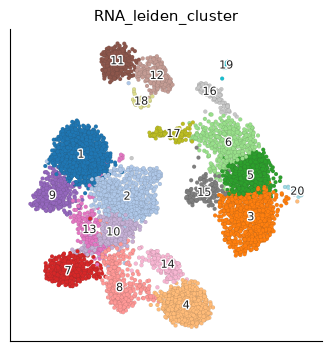

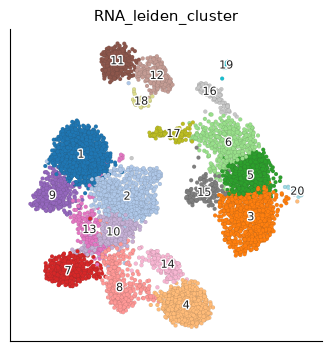

In [3]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="RNA_leiden_cluster",
    show=False,
).figure

In [4]:
ds.show_zarr_tree(depth=1)

/
├── ADT
│   ├── counts (7865, 17) uint32
│   ├── featureData
│   └── normed__I__I
├── RNA
│   ├── counts (7865, 33538) uint32
│   ├── featureData
│   ├── markers
│   ├── normed__I__hvgs
│   └── summary_stats_I
└── cellData
    ├── ADT_UMAP1 (7865,) float32
    ├── ADT_UMAP2 (7865,) float32
    ├── ADT_leiden_cluster (7865,) int64
    ├── ADT_nCounts (7865,) float64
    ├── ADT_nFeatures (7865,) float64
    ├── I (7865,) bool
    ├── RNA_UMAP1 (7865,) float32
    ├── RNA_UMAP2 (7865,) float32
    ├── RNA_cluster (7865,) int64
    ├── RNA_leiden_cluster (7865,) int64
    ├── RNA_nCounts (7865,) float64
    ├── RNA_nFeatures (7865,) float64
    ├── RNA_percentMito (7865,) float64
    ├── RNA_percentRibo (7865,) float64
    ├── RNA_tSNE1 (7865,) float64
    ├── RNA_tSNE2 (7865,) float64
    ├── ids (7865,) <U18
    └── names (7865,) <U18



In [5]:
ds.show_zarr_tree(start="cellData")

/cellData
├── ADT_UMAP1 (7865,) float32
├── ADT_UMAP2 (7865,) float32
├── ADT_leiden_cluster (7865,) int64
├── ADT_nCounts (7865,) float64
├── ADT_nFeatures (7865,) float64
├── I (7865,) bool
├── RNA_UMAP1 (7865,) float32
├── RNA_UMAP2 (7865,) float32
├── RNA_cluster (7865,) int64
├── RNA_leiden_cluster (7865,) int64
├── RNA_nCounts (7865,) float64
├── RNA_nFeatures (7865,) float64
├── RNA_percentMito (7865,) float64
├── RNA_percentRibo (7865,) float64
├── RNA_tSNE1 (7865,) float64
├── RNA_tSNE2 (7865,) float64
├── ids (7865,) <U18
└── names (7865,) <U18

  RNA_percentMito: shape=(7865,), dtype=float64, chunks=(100000,)
  ADT_UMAP2: shape=(7865,), dtype=float32, chunks=(100000,)
  RNA_tSNE2: shape=(7865,), dtype=float64, chunks=(100000,)
  ADT_nFeatures: shape=(7865,), dtype=float64, chunks=(100000,)
  RNA_tSNE1: shape=(7865,), dtype=float64, chunks=(100000,)
  ADT_UMAP1: shape=(7865,), dtype=float32, chunks=(100000,)
  names: shape=(7865,), dtype=<U18, chunks=(100000,)
  I: shape=(786

In [6]:
ds.show_zarr_tree(start="RNA", depth=1)

/RNA
├── counts (7865, 33538) uint32
├── featureData
│   ├── I (33538,) bool
│   ├── I__hvgs (33538,) bool
│   ├── dropOuts (33538,) int64
│   ├── ids (33538,) <U15
│   ├── nCells (33538,) int64
│   └── names (33538,) <U16
├── markers
│   ├── I__RNA_cluster
│   └── I__RNA_leiden_cluster
├── normed__I__hvgs
│   ├── data (7549, 1995) float64
│   └── reduction__pca__30__I
└── summary_stats_I
    ├── avg (33538,) float64
    ├── c_var__200__0.1 (33538,) float64
    ├── normed_n (33538,) float64
    ├── normed_tot (33538,) float64
    ├── nz_mean (33538,) float64
    └── sigmas (33538,) float64

  counts: shape=(7865, 33538), dtype=uint32, chunks=(2000, 1000)


In [7]:
ds.show_zarr_tree(start="RNA/featureData", depth=1)

/RNA/featureData
├── I (33538,) bool
├── I__hvgs (33538,) bool
├── dropOuts (33538,) int64
├── ids (33538,) <U15
├── nCells (33538,) int64
└── names (33538,) <U16

  names: shape=(33538,), dtype=<U16, chunks=(100000,)
  I: shape=(33538,), dtype=bool, chunks=(100000,)
  I__hvgs: shape=(33538,), dtype=bool, chunks=(100000,)
  nCells: shape=(33538,), dtype=int64, chunks=(100000,)
  ids: shape=(33538,), dtype=<U15, chunks=(100000,)
  dropOuts: shape=(33538,), dtype=int64, chunks=(100000,)


In [8]:
ds.cells.head()

,I,ids,names,RNA_percentMito,RNA_tSNE2,ADT_nFeatures,ADT_UMAP2,ADT_UMAP1,RNA_percentRibo,RNA_tSNE1,ADT_nCounts,RNA_nFeatures,RNA_leiden_cluster,RNA_cluster,RNA_UMAP2,RNA_nCounts,ADT_leiden_cluster,RNA_UMAP1
0,True,AAACCCAAGATTGTGA-1,AAACCCAAGATTGTGA-1,8.668831,-18.08830,17.0,9.510007,-13.884989,15.259740,-4.26865,981.0,2194.0,3,4,-7.417822,6160.0,16,29.421942
1,True,AAACCCACATCGGTTA-1,AAACCCACATCGGTTA-1,6.316103,-14.88920,17.0,10.784672,-5.097915,19.037688,5.02671,1475.0,2093.0,3,4,-12.649998,6713.0,15,30.801842
2,True,AAACCCAGTACCGCGT-1,AAACCCAGTACCGCGT-1,8.056090,-18.83030,17.0,12.961405,-7.885502,16.002200,-14.91320,7149.0,1518.0,5,5,4.256729,3637.0,9,29.397541
3,True,AAACCCAGTATCGAAA-1,AAACCCAGTATCGAAA-1,9.003215,-3.35003,17.0,11.531997,12.072053,18.729904,16.69630,6831.0,737.0,4,3,-32.227364,1244.0,2,5.441914
4,True,AAACCCAGTCGTCATA-1,AAACCCAGTCGTCATA-1,6.204519,-1.37607,17.0,12.290624,13.928782,16.353887,18.37000,6839.0,1240.0,4,3,-30.397615,2611.0,2,7.166490


In [9]:
ds.RNA.feats.head()

,I,ids,names,nCells,dropOuts,I__hvgs
0,False,ENSG00000243485,MIR1302-2HG,0,7865,False
1,False,ENSG00000237613,FAM138A,0,7865,False
2,False,ENSG00000186092,OR4F5,0,7865,False
3,False,ENSG00000238009,AL627309.1,12,7853,False
4,False,ENSG00000239945,AL627309.3,0,7865,False


In [10]:
ds.cells.to_pandas_dataframe(
    columns=["ids", "RNA_nCounts", "RNA_nFeatures", "RNA_leiden_cluster"]
).set_index("ids")

,RNA_nCounts,RNA_nFeatures,RNA_leiden_cluster
ids,,,
AAACCCAAGATTGTGA-1,6160.0,2194.0,3
AAACCCACATCGGTTA-1,6713.0,2093.0,3
AAACCCAGTACCGCGT-1,3637.0,1518.0,5
AAACCCAGTATCGAAA-1,1244.0,737.0,4
AAACCCAGTCGTCATA-1,2611.0,1240.0,4
...,...,...,...
TTTGTTGGTTCAAGTC-1,5830.0,2178.0,18
TTTGTTGGTTGCATGT-1,4096.0,1256.0,9
TTTGTTGGTTGCGGCT-1,5524.0,1907.0,3


In [11]:
cluster_labels = ds.cells.fetch("RNA_leiden_cluster")
cluster_labels.shape, ds.cells.fetch_all("RNA_leiden_cluster").shape

((7549,), (7865,))

In [12]:
is_cluster_1 = cluster_labels == 1
ds.cells.insert(column_name="is_cluster_1", values=is_cluster_1, overwrite=True)

In [13]:
ds.cells.insert(
    column_name="is_cluster_1",
    values=is_cluster_1,
)

ValueError: ERROR: is_cluster_1 already exists. Please set `overwrite` to True to overwrite.

In [14]:
ds.RNA.rawData

ChunkedArray(shape=(7865, 33538), dtype=uint32, chunksize=(2000, 33538), numblocks=4)

In [15]:
ds.RNA.normed()

ChunkedArray(shape=(7549, 13550), dtype=float64, chunksize=(2000, 13550), numblocks=4)

In [16]:
import inspect

print(inspect.getsource(ds.RNA.normMethod))

def norm_lib_size(assay: "Assay", counts: ChunkedArray) -> ChunkedArray:
    """Performs library size normalization on the data. This is the default
    method for RNA assays.

    Args:
        assay: An instance of the assay object
        counts: A chunked array with raw counts data

    Returns:  A chunked array (delayed matrix) containing normalized data.
    """
    assert assay.sf is not None and assay.scalar is not None
    return assay.sf * counts / assay.scalar.reshape(-1, 1)



In [17]:
def my_cool_normalization_method(assay, counts):
    import numpy as np

    lib_size = counts.sum(axis=1).reshape(-1, 1)
    return np.log2(counts / lib_size)


ds.RNA.normMethod = my_cool_normalization_method
ds.RNA.normMethod = scarf.assay.norm_dummy

In [18]:
ds.show_zarr_tree(start="RNA/normed__I__hvgs")

/RNA/normed__I__hvgs
├── data (7549, 1995) float64
└── reduction__pca__30__I
    ├── ann__l2__63__63__48__4466
    │   └── knn__21
    ├── kmeans__100__4466
    │   ├── cluster_centers (100, 30) float64
    │   └── cluster_labels (7549,) float64
    ├── mu (1995,) float64
    ├── reduction (1995, 30) float64
    └── sigma (1995,) float64

  data: shape=(7549, 1995), dtype=float64, chunks=(2000, 2000)


/home/parashar/scarf/.venv/lib/python3.12/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at ann_idx is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [19]:
ds.load_graph(
    from_assay="RNA",
    cell_key="I",
    feat_key="hvgs",
    symmetric=False,
    upper_only=False,
)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 158529 stored elements and shape (7549, 7549)>

In [20]:
ds.show_zarr_tree(start="RNA/markers", depth=2)

/RNA/markers
├── I__RNA_cluster
│   ├── 1
│   │   ├── feature_index (13550,) int64
│   │   ├── fold_change (13550,) float64
│   │   ├── frac_exp (13550,) float64
│   │   ├── frac_exp_rest (13550,) float64
│   │   ├── mean (13550,) float64
│   │   ├── mean_rest (13550,) float64
│   │   └── score (13550,) float64
│   ├── 10
│   │   ├── feature_index (13550,) int64
│   │   ├── fold_change (13550,) float64
│   │   ├── frac_exp (13550,) float64
│   │   ├── frac_exp_rest (13550,) float64
│   │   ├── mean (13550,) float64
│   │   ├── mean_rest (13550,) float64
│   │   └── score (13550,) float64
│   ├── 11
│   │   ├── feature_index (13550,) int64
│   │   ├── fold_change (13550,) float64
│   │   ├── frac_exp (13550,) float64
│   │   ├── frac_exp_rest (13550,) float64
│   │   ├── mean (13550,) float64
│   │   ├── mean_rest (13550,) float64
│   │   └── score (13550,) float64
│   ├── 12
│   │   ├── feature_index (13550,) int64
│   │   ├── fold_change (13550,) float64
│   │   ├── frac_exp (13550,) 

In [21]:
ds.get_markers(
    group_key="RNA_leiden_cluster",
    group_id="1",
    min_score=0.1,
    min_frac_exp=0.1,
).head()

,group_id,feature_name,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,feature_index
0,1,NOG,0.46887,0.06760,0.00335,0.18144,0.01374,20.18853,2.741646e-164,11175
1,1,EPHX2,0.40393,0.07962,0.00922,0.22660,0.03633,8.63402,2.088295e-136,5926
2,1,ANKRD55,0.38725,0.03994,0.00264,0.12397,0.01248,15.12881,4.635440e-97,3599
3,1,CHRM3-AS2,0.37763,0.10506,0.01346,0.28325,0.04928,7.80488,5.298034e-163,1351
4,1,AC005842.1,0.34574,0.05235,0.00668,0.15928,0.02812,7.84134,1.677540e-86,8098


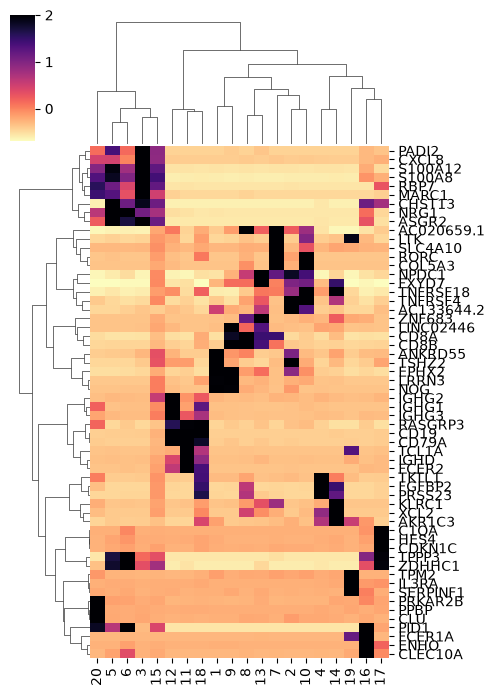

In [22]:
splt.marker_heatmap(
    ds,
    group_key="RNA_leiden_cluster",
    topn=3,
    figsize=(5, 7),
)

In [23]:
ds.export_markers_to_csv(
    group_key="RNA_leiden_cluster",
    csv_filename="test.csv",
    min_score=0.2,
    min_frac_exp=0.1,
)